# 15. Causal Inference — Campaign Effectiveness

## Business Case

A bank runs a campaign:

> **Offer a Personal Loan to selected customers.**

After the campaign, management observes that customers who received the campaign converted at a higher rate.

But the key question is:

> **Did the campaign cause the additional conversions?**

This is a causal inference problem.

---

### Why simple comparison can be misleading

Suppose:

```text
Treatment conversion = 12%
Control conversion   =  8%
```

Naively:

```text
12% - 8% = +4 percentage points
```

But perhaps the bank preferentially targeted customers who were already:

- more digitally engaged,
- wealthier,
- more active,
- existing multi-product customers,
- more likely to take a loan.

Therefore:

```text
Observed difference
≠ necessarily
Causal effect
```

This notebook demonstrates an observational causal inference workflow using synthetic banking data.

## 1. Causal Inference vs Prediction

### Prediction

Question:

> Which customers are likely to convert?

```text
Customer features
       ↓
Prediction model
       ↓
P(Conversion)
```

### Causal Inference

Question:

> What would happen if the same customer received the campaign versus did not receive it?

Conceptually:

```text
Same customer
   ├── Campaign
   └── No Campaign
         ↓
Compare outcomes
```

The problem is that we cannot observe both outcomes for the same customer at the same time.

This is the **fundamental problem of causal inference**.

## 2. Potential Outcomes

For each customer:

```text
Y(1) = outcome if treated
Y(0) = outcome if not treated
```

Individual treatment effect:

```text
ITE = Y(1) - Y(0)
```

But for each customer we observe only one:

```text
Treatment → Y(1)
Control   → Y(0)
```

The other potential outcome is missing.

Causal inference attempts to estimate these missing counterfactual outcomes.

## 3. Key Causal Estimands

### Average Treatment Effect — ATE

```text
ATE = E[Y(1) - Y(0)]
```

Question:

> What is the average effect of the campaign across the population?

### Average Treatment Effect on the Treated — ATT

```text
ATT = E[Y(1) - Y(0) | T=1]
```

Question:

> What was the average effect among customers who actually received the campaign?

### Conditional Average Treatment Effect — CATE

```text
CATE(X)
```

Question:

> How does the treatment effect differ across customer characteristics?

## 4. Business Objective

We want to answer:

1. Did the campaign increase conversion?
2. How large was the incremental effect?
3. Which customer segments benefited most?
4. Was the campaign economically worthwhile?
5. Who should receive future campaigns?

This is more informative than simply reporting campaign conversion.

## 5. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, scikit-learn for propensity models and matching, and Matplotlib/Seaborn for visualisation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

df=pd.read_csv("bank_campaign_causal_sample.csv")

print("Customers:",len(df))
display(df.head())
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


Customers: 6000


,Customer_ID,Age,Monthly_Income,Tenure_Months,Product_Count,Digital_Engagement,Balance,Prior_Monthly_Transactions,Segment,Treatment,Campaign_Name,Conversion,Propensity_True
0,C00001,25,21454163.0,100,6,52,9832455.0,31,Mass,1,Personal Loan Offer,0,0.644120
1,C00002,55,7921147.0,11,3,42,30903871.0,23,Mass,1,Personal Loan Offer,0,0.218402
2,C00003,50,3000000.0,178,4,26,10661096.0,26,Mass,1,Personal Loan Offer,0,0.289468
3,C00004,40,4540684.0,130,1,19,7236638.0,21,Affluent,0,Personal Loan Offer,0,0.304279
4,C00005,40,26227317.0,85,1,23,156224382.0,24,Mass,1,Personal Loan Offer,0,0.206126


## 6. Dataset Dictionary

Campaign fields are documented — treatment assignment, conversion, and the customer attributes measured before the campaign. Pre-treatment covariates are the raw material for building comparable treated and untreated groups.


In [2]:
dictionary=pd.DataFrame({
    "Column":[
        "Customer_ID","Age","Monthly_Income","Tenure_Months",
        "Product_Count","Digital_Engagement","Balance",
        "Prior_Monthly_Transactions","Segment","Treatment",
        "Campaign_Name","Conversion"
    ],
    "Meaning":[
        "Customer identifier",
        "Customer age",
        "Monthly income",
        "Relationship tenure",
        "Number of existing products",
        "Digital engagement score before campaign",
        "Account balance before campaign",
        "Prior transaction activity",
        "Customer segment",
        "1 = received campaign, 0 = did not",
        "Campaign name",
        "1 = converted, 0 = did not convert"
    ]
})
display(dictionary)

,Column,Meaning
0,Customer_ID,Customer identifier
1,Age,Customer age
2,Monthly_Income,Monthly income
3,Tenure_Months,Relationship tenure
4,Product_Count,Number of existing products
5,Digital_Engagement,Digital engagement score before campaign
6,Balance,Account balance before campaign
7,Prior_Monthly_Transactions,Prior transaction activity
8,Segment,Customer segment
9,Treatment,"1 = received campaign, 0 = did not"


## 7. Treatment and Outcome

```text
Treatment
1 → Received campaign
0 → Did not receive campaign

Outcome
1 → Purchased / converted
0 → Did not purchase
```

Important:

All features used for causal adjustment should be measured **before treatment**.

Do not use post-campaign variables as confounders.

## 8. Data Quality

Missing values, dtypes and duplicate rows are inspected. Bad rows bias the propensity model and therefore the estimated campaign effect itself.


In [3]:
print("Missing values:")
display(df.isna().sum().to_frame("Missing"))

print("Duplicate customers:",df["Customer_ID"].duplicated().sum())

print("\nTreatment distribution:")
display(df["Treatment"].value_counts(normalize=True).rename("Share"))

print("\nOverall conversion:")
print(round(df["Conversion"].mean(),3))

Missing values:


,Missing
Customer_ID,0
Age,0
Monthly_Income,0
Tenure_Months,0
Product_Count,0
Digital_Engagement,0
Balance,0
Prior_Monthly_Transactions,0
Segment,0
Treatment,0


Duplicate customers: 0

Treatment distribution:


Treatment
0    0.530833
1    0.469167
Name: Share, dtype: float64


Overall conversion:
0.281


## 9. Exploratory Analysis

Raw conversion rates of treated versus untreated customers are compared. The naive difference is shown to be misleading, since treated and control customers started from different profiles.


In [4]:
treatment_summary=(
    df.groupby("Treatment")["Conversion"]
      .agg(["count","mean"])
      .rename(columns={"mean":"Conversion_Rate"})
)

display(treatment_summary.round(3))

,count,Conversion_Rate
Treatment,,
0,3185,0.208
1,2815,0.363


Saved: output/9-exploratory-analysis.png


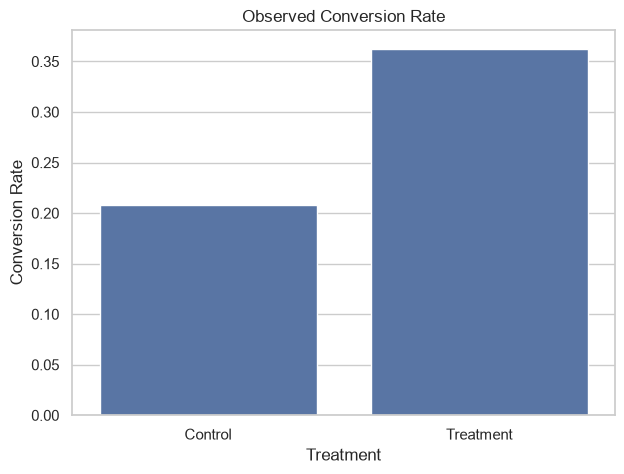

In [5]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x="Treatment",
    y="Conversion",
    errorbar=None
)
plt.xticks([0,1],["Control","Treatment"])
plt.title("Observed Conversion Rate")
plt.ylabel("Conversion Rate")
save_plot("9-exploratory-analysis.png")
plt.show()

## 10. Naive Treatment Effect

The simplest estimate is:

```text
Observed Treatment Conversion
-
Observed Control Conversion
```

This is sometimes called the **difference in means**.

It is unbiased under strong assumptions such as randomized treatment.

In observational data, however, treatment assignment may be confounded.

In [6]:
control_rate=df.loc[df["Treatment"]==0,"Conversion"].mean()
treatment_rate=df.loc[df["Treatment"]==1,"Conversion"].mean()

naive_effect=treatment_rate-control_rate

print("Treatment conversion:",round(treatment_rate,4))
print("Control conversion:",round(control_rate,4))
print("Naive treatment effect:",round(naive_effect,4))
print("Percentage points:",round(naive_effect*100,2))

Treatment conversion: 0.3627
Control conversion: 0.2085
Naive treatment effect: 0.1542
Percentage points: 15.42


## 11. Check for Selection Bias

Compare customer characteristics between treatment and control.

If treated customers are systematically different, simple comparison may be confounded.

In [7]:
numeric_cols=[
    "Age","Monthly_Income","Tenure_Months",
    "Product_Count","Digital_Engagement",
    "Balance","Prior_Monthly_Transactions"
]

balance_table=df.groupby("Treatment")[numeric_cols].mean().T
balance_table.columns=["Control","Treatment"]

display(balance_table.round(2))

,Control,Treatment
Age,43.03,42.86
Monthly_Income,13746292.87,14292762.61
Tenure_Months,91.33,91.50
Product_Count,3.31,3.77
Digital_Engagement,50.25,60.63
Balance,33416388.74,33666821.63
Prior_Monthly_Transactions,24.90,25.17


## 12. Standardized Mean Difference

A common balance diagnostic is:

```text
SMD =
Difference in group means
/
Pooled standard deviation
```

Roughly:

```text
|SMD| < 0.10
```

is often considered a useful indication of good balance, although thresholds should be treated as diagnostics rather than universal rules.

In [8]:
def smd(data,col,treatment_col="Treatment"):
    x=data.loc[data[treatment_col]==1,col]
    y=data.loc[data[treatment_col]==0,col]
    pooled=np.sqrt((x.var()+y.var())/2)
    return (x.mean()-y.mean())/pooled

smd_table=pd.DataFrame({
    "Feature":numeric_cols,
    "SMD":[smd(df,c) for c in numeric_cols]
})

display(smd_table.round(3))

,Feature,SMD
0,Age,-0.013
1,Monthly_Income,0.066
2,Tenure_Months,0.003
3,Product_Count,0.270
4,Digital_Engagement,0.400
5,Balance,0.006
6,Prior_Monthly_Transactions,0.054


Saved: output/12-standardized-mean-difference.png


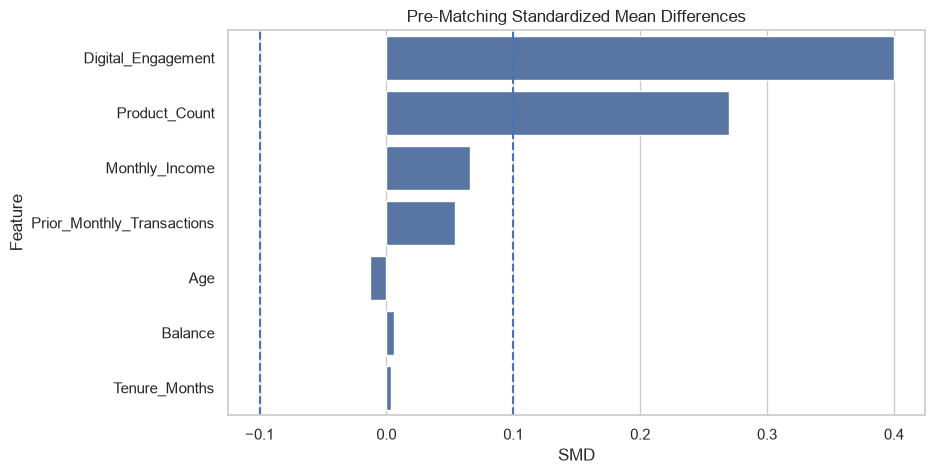

In [9]:
plt.figure(figsize=(9,5))
plot=smd_table.copy()
plot["Abs_SMD"]=plot["SMD"].abs()

sns.barplot(
    data=plot.sort_values("Abs_SMD",ascending=False),
    x="SMD",
    y="Feature"
)

plt.axvline(.1,ls="--")
plt.axvline(-.1,ls="--")
plt.title("Pre-Matching Standardized Mean Differences")
save_plot("12-standardized-mean-difference.png")
plt.show()

## 13. Propensity Score

The propensity score is:

```text
e(X) = P(Treatment = 1 | X)
```

It estimates the probability that a customer receives the campaign based on observed pre-treatment characteristics.

Example:

```text
Customer A
Income = high
Digital Engagement = high
Products = many

        ↓

Propensity Score = 0.82
```

This means the model estimates that this customer had a relatively high probability of receiving the campaign.

## 14. Estimate Propensity Score

We use Logistic Regression with pre-treatment variables.

Important:

The propensity model estimates **treatment assignment**, not conversion.

In [10]:
prop_features=[
    "Age","Monthly_Income","Tenure_Months",
    "Product_Count","Digital_Engagement",
    "Balance","Prior_Monthly_Transactions",
    "Segment"
]

X_prop=df[prop_features]
t=df["Treatment"]

cat_cols=["Segment"]
num_cols=[c for c in prop_features if c not in cat_cols]

prep=ColumnTransformer([
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols),
    ("num",StandardScaler(),num_cols)
])

propensity_model=Pipeline([
    ("prep",prep),
    ("model",LogisticRegression(max_iter=1000))
])

propensity_model.fit(X_prop,t)

df["Propensity_Score"]=propensity_model.predict_proba(X_prop)[:,1]

print("Propensity AUC:",
      round(roc_auc_score(t,df["Propensity_Score"]),3))

display(
    df[[
        "Customer_ID","Treatment",
        "Propensity_Score"
    ]].head()
)

Propensity AUC: 0.644


,Customer_ID,Treatment,Propensity_Score
0,C00001,1,0.563966
1,C00002,1,0.347564
2,C00003,1,0.328059
3,C00004,0,0.239351
4,C00005,1,0.275179


## 15. Propensity Score Overlap

Propensity-score distributions of treated and control groups are overlaid. Good overlap means every treated customer has comparable controls; regions without overlap cannot support any causal estimate.


Saved: output/15-propensity-score-overlap.png


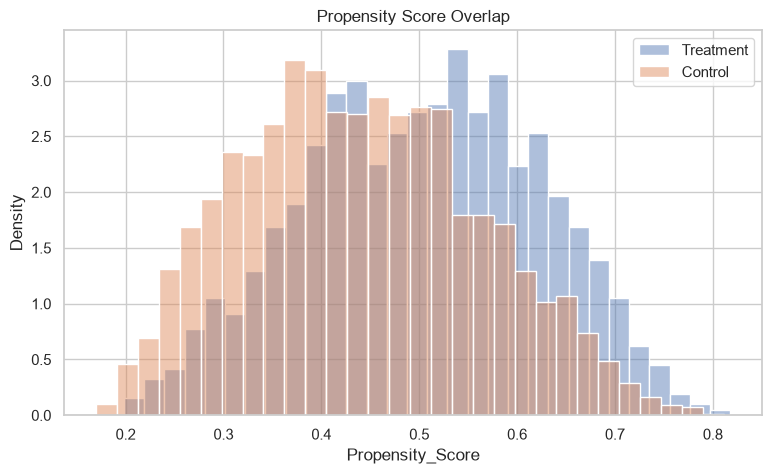

In [11]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df[df["Treatment"]==1],
    x="Propensity_Score",
    stat="density",
    bins=30,
    alpha=.45,
    label="Treatment"
)

sns.histplot(
    data=df[df["Treatment"]==0],
    x="Propensity_Score",
    stat="density",
    bins=30,
    alpha=.45,
    label="Control"
)

plt.title("Propensity Score Overlap")
plt.legend()
save_plot("15-propensity-score-overlap.png")
plt.show()

## 16. Why Overlap Matters

Causal comparison requires **common support / positivity**.

Conceptually:

```text
For similar customer characteristics,
there should be some customers who
received treatment and some who did not.
```

If a particular type of customer is always treated:

```text
No comparable control
```

then its treatment effect is difficult to estimate from observational data.

## 17. Propensity Score Matching

We match treatment customers with control customers having similar propensity scores.

Conceptually:

```text
Treatment Customer
Propensity = 0.71
       ↓
Closest Control
Propensity = 0.70
```

The goal is to create a more comparable treatment and control population.

In [12]:
treated=df[df["Treatment"]==1].copy()
control=df[df["Treatment"]==0].copy()

nn=NearestNeighbors(
    n_neighbors=1,
    metric="euclidean"
)

nn.fit(control[["Propensity_Score"]])

dist,idx=nn.kneighbors(
    treated[["Propensity_Score"]]
)

treated["Match_Distance"]=dist.ravel()
treated["Control_Index"]=idx.ravel()

# Caliper: maximum acceptable propensity distance
caliper=.05

matched_treated=treated[
    treated["Match_Distance"]<=caliper
].copy()

matched_control=control.iloc[
    matched_treated["Control_Index"].values
].copy()

matched_control.index=matched_treated.index

print("Treated before:",len(treated))
print("Matched pairs:",len(matched_treated))

Treated before: 2815
Matched pairs: 2815


## 18. Check Matched Balance

Covariate means are re-compared after propensity matching. Balance confirms the matched groups are genuinely comparable, which is what licenses a causal reading of the uplift estimate.


In [13]:
matched_rows=[]

for col in numeric_cols:
    a=matched_treated[col]
    b=matched_control[col]
    pooled=np.sqrt((a.var()+b.var())/2)
    matched_rows.append({
        "Feature":col,
        "SMD_After_Matching":(a.mean()-b.mean())/pooled
    })

matched_smd=pd.DataFrame(matched_rows)

display(matched_smd.round(3))

,Feature,SMD_After_Matching
0,Age,0.044
1,Monthly_Income,0.017
2,Tenure_Months,0.012
3,Product_Count,-0.031
4,Digital_Engagement,0.037
5,Balance,-0.010
6,Prior_Monthly_Transactions,-0.036


In [14]:
before=smd_table.rename(
    columns={"SMD":"SMD_Before"}
)

balance_compare=before.merge(
    matched_smd,
    on="Feature"
)

display(balance_compare.round(3))

,Feature,SMD_Before,SMD_After_Matching
0,Age,-0.013,0.044
1,Monthly_Income,0.066,0.017
2,Tenure_Months,0.003,0.012
3,Product_Count,0.270,-0.031
4,Digital_Engagement,0.400,0.037
5,Balance,0.006,-0.010
6,Prior_Monthly_Transactions,0.054,-0.036


Saved: output/18-check-matched-balance.png


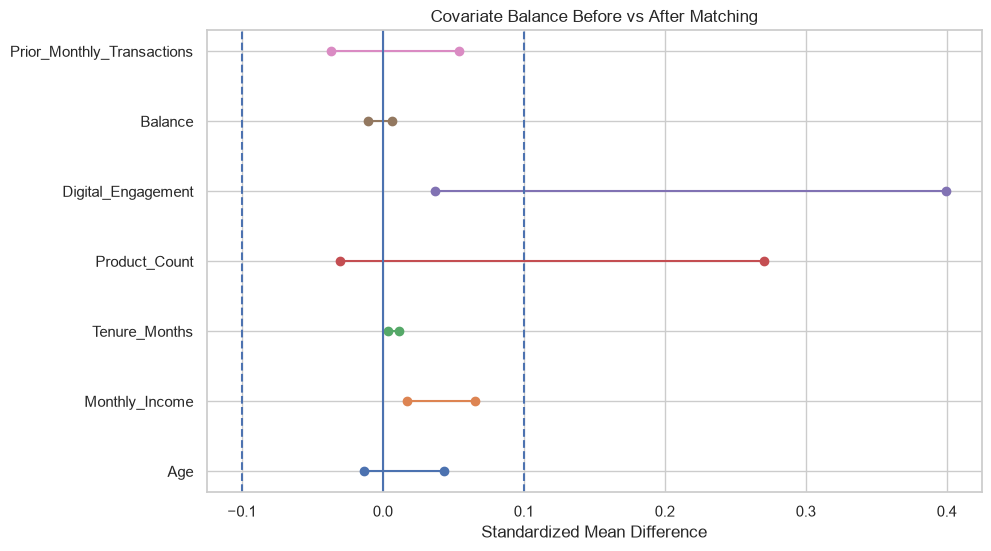

In [15]:
plt.figure(figsize=(10,6))

plot=balance_compare.copy()
plot["Feature"]=plot["Feature"].astype(str)

for _,row in plot.iterrows():
    plt.plot(
        [row["SMD_Before"],row["SMD_After_Matching"]],
        [row["Feature"],row["Feature"]],
        marker="o"
    )

plt.axvline(0,ls="-")
plt.axvline(.1,ls="--")
plt.axvline(-.1,ls="--")

plt.title("Covariate Balance Before vs After Matching")
plt.xlabel("Standardized Mean Difference")
save_plot("18-check-matched-balance.png")
plt.show()

## 19. Estimate ATT After Matching

Now compare outcomes among matched treatment and control customers.

```text
ATT ≈
Mean(Y treated matched)
-
Mean(Y control matched)
```

This estimates the treatment effect among customers who received the campaign, under the causal assumptions.

In [16]:
att=(
    matched_treated["Conversion"].mean()
    -
    matched_control["Conversion"].mean()
)

print("Matched treatment conversion:",
      round(matched_treated["Conversion"].mean(),4))

print("Matched control conversion:",
      round(matched_control["Conversion"].mean(),4))

print("Estimated ATT:",
      round(att,4))

print("Percentage points:",
      round(att*100,2))

Matched treatment conversion: 0.3627
Matched control conversion: 0.2359
Estimated ATT: 0.1268
Percentage points: 12.68


## 20. ATE vs ATT

### ATE

```text
Effect across the target population
```

### ATT

```text
Effect among customers actually treated
```

In observational campaign analysis, ATT is often especially relevant when the business question is:

> "Did the campaign work for the customers we actually contacted?"

The estimand should be chosen before analysis based on the business question.

## 21. Segment-Level Treatment Effect

The average effect can hide important differences.

For example:

```text
Mass       → +1%
Affluent   → +5%
Priority   → +8%
```

This motivates heterogeneous treatment effect analysis.

In [17]:
seg_results=[]

for seg,group in df.groupby("Segment"):
    tr=group[group["Treatment"]==1]["Conversion"]
    co=group[group["Treatment"]==0]["Conversion"]

    seg_results.append({
        "Segment":seg,
        "Treatment_N":len(tr),
        "Control_N":len(co),
        "Treatment_Rate":tr.mean(),
        "Control_Rate":co.mean(),
        "Naive_Difference":tr.mean()-co.mean()
    })

segment_effect=pd.DataFrame(seg_results)

display(segment_effect.round(4))

,Segment,Treatment_N,Control_N,Treatment_Rate,Control_Rate,Naive_Difference
0,Affluent,825,860,0.4000,0.2430,0.1570
1,Mass,1647,2044,0.3194,0.1840,0.1354
2,Priority,343,281,0.4810,0.2811,0.1999


Saved: output/21-segment-level-treatment-effect.png


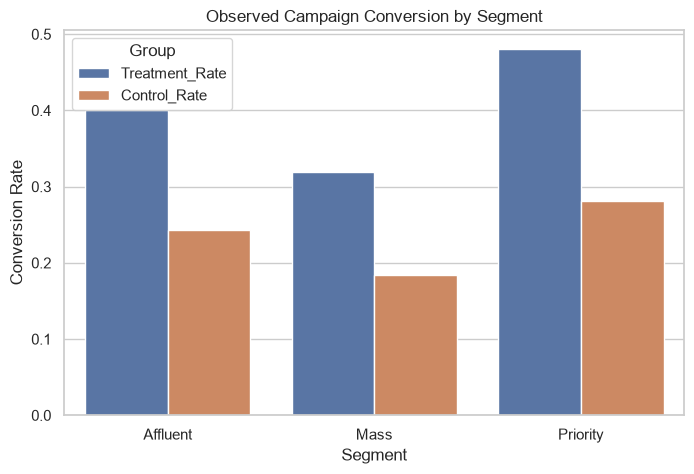

In [18]:
plt.figure(figsize=(8,5))

plot=segment_effect.melt(
    id_vars="Segment",
    value_vars=["Treatment_Rate","Control_Rate"],
    var_name="Group",
    value_name="Conversion_Rate"
)

sns.barplot(
    data=plot,
    x="Segment",
    y="Conversion_Rate",
    hue="Group"
)

plt.title("Observed Campaign Conversion by Segment")
plt.ylabel("Conversion Rate")
save_plot("21-segment-level-treatment-effect.png")
plt.show()

## 22. Individual Treatment Effect

For each customer:

```text
ITE = Y(1) - Y(0)
```

But we cannot observe both outcomes.

A practical modeling approach is to estimate:

```text
Potential outcome under treatment
Potential outcome under control
```

and then calculate:

```text
Estimated ITE
=
Predicted Y(1)
-
Predicted Y(0)
```

This is sometimes called an **uplift / treatment-effect model**.

## 23. Simple T-Learner Concept

A T-Learner trains two separate models:

```text
Treatment Customers
       ↓
Model T
       ↓
Y_hat(1)

Control Customers
       ↓
Model C
       ↓
Y_hat(0)
```

Then:

```text
CATE / ITE
=
Y_hat(1) - Y_hat(0)
```

This is an educational implementation, not a guarantee of causal identification.

In [19]:
from sklearn.ensemble import RandomForestRegressor

outcome_features=[
    "Age","Monthly_Income","Tenure_Months",
    "Product_Count","Digital_Engagement",
    "Balance","Prior_Monthly_Transactions"
]

train=df.copy()

tr=train[train["Treatment"]==1]
co=train[train["Treatment"]==0]

model_t=RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

model_c=RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

model_t.fit(tr[outcome_features],tr["Conversion"])
model_c.fit(co[outcome_features],co["Conversion"])

mu1=model_t.predict(df[outcome_features])
mu0=model_c.predict(df[outcome_features])

df["Predicted_Y1"]=mu1
df["Predicted_Y0"]=mu0
df["Estimated_CATE"]=mu1-mu0

display(
    df[[
        "Customer_ID","Segment",
        "Treatment","Estimated_CATE"
    ]].sort_values(
        "Estimated_CATE",
        ascending=False
    ).head(20)
)

,Customer_ID,Segment,Treatment,Estimated_CATE
3425,C03426,Mass,1,0.546520
2802,C02803,Affluent,1,0.544207
4815,C04816,Priority,1,0.526778
5711,C05712,Mass,1,0.519635
4801,C04802,Affluent,1,0.508926
4479,C04480,Priority,1,0.498114
259,C00260,Priority,1,0.495483
4553,C04554,Mass,0,0.494123
3491,C03492,Priority,1,0.490106
850,C00851,Affluent,1,0.490058


## 24. Uplift Ranking

Now customers can be ranked by **incremental effect**, rather than probability of conversion.

This distinction is important.

### Response model

> Who is likely to buy?

### Uplift model

> Who is more likely to buy **because of the campaign**?

A customer with high natural purchase propensity may buy even without the campaign.

That customer is not necessarily the best campaign target.

## 25. Four Customer Types

A useful uplift framework:

```text
                 Would buy without campaign?
                 Low              High

Campaign
helps       Persuadable       Sure Thing

Campaign
doesn't     Lost Cause        Sleeping Dog
```

More formally:

### Persuadables

Likely to respond because of treatment.

### Sure Things

Likely to buy regardless.

### Lost Causes

Unlikely to buy regardless.

### Sleeping Dogs

Campaign may not help and can potentially have undesirable effects.

These categories are conceptual and require careful estimation.

## 26. Campaign Targeting Strategy

A future campaign can prioritize:

```text
High estimated incremental effect
        ↓
Check eligibility
        ↓
Check expected value
        ↓
Campaign
```

This is different from:

```text
Highest conversion probability
```

The objective should be incremental impact, not simply response propensity.

In [20]:
uplift_summary=(
    df.assign(
        Uplift_Decile=pd.qcut(
            df["Estimated_CATE"],
            10,
            labels=False,
            duplicates="drop"
        )+1
    )
    .groupby("Uplift_Decile")["Estimated_CATE"]
    .agg(["count","mean","min","max"])
    .reset_index()
)

display(uplift_summary.round(4))

,Uplift_Decile,count,mean,min,max
0,1,600,-0.1440,-0.5646,-0.0521
1,2,600,-0.0207,-0.0521,0.0038
2,3,600,0.0243,0.0038,0.0439
3,4,600,0.0610,0.0439,0.0777
4,5,600,0.0918,0.0778,0.1087
5,6,600,0.1266,0.1087,0.1454
6,7,600,0.1669,0.1454,0.1899
7,8,600,0.2161,0.1900,0.2413
8,9,600,0.2718,0.2413,0.3073
9,10,600,0.3659,0.3074,0.5465


## 27. Incremental Business Impact

Suppose:

```text
Campaign population = 6,000
Estimated ATT = 0.03
```

Then estimated incremental conversions:

```text
6,000 × 3%
= 180 incremental conversions
```

If:

```text
Profit per conversion = Rp 1,500,000
```

then:

```text
Incremental profit
= 180 × Rp 1,500,000
= Rp 270,000,000
```

Then subtract campaign cost to estimate incremental ROI.

In [21]:
campaign_population=len(matched_treated)
incremental_conversions=campaign_population*att

profit_per_conversion=1_500_000
campaign_cost=50_000_000

incremental_profit=(
    incremental_conversions*profit_per_conversion
)

net_incremental_profit=incremental_profit-campaign_cost

roi=net_incremental_profit/campaign_cost

business_impact=pd.DataFrame({
    "Metric":[
        "Matched Campaign Customers",
        "Estimated ATT",
        "Estimated Incremental Conversions",
        "Profit per Conversion",
        "Estimated Incremental Profit",
        "Campaign Cost",
        "Net Incremental Profit",
        "Incremental ROI"
    ],
    "Value":[
        campaign_population,
        att,
        incremental_conversions,
        profit_per_conversion,
        incremental_profit,
        campaign_cost,
        net_incremental_profit,
        roi
    ]
})

display(business_impact)

,Metric,Value
0,Matched Campaign Customers,2.815000e+03
1,Estimated ATT,1.268206e-01
2,Estimated Incremental Conversions,3.570000e+02
3,Profit per Conversion,1.500000e+06
4,Estimated Incremental Profit,5.355000e+08
5,Campaign Cost,5.000000e+07
6,Net Incremental Profit,4.855000e+08
7,Incremental ROI,9.710000e+00


## 28. Why Randomized Experiments Are Stronger

If possible, the bank should use a randomized controlled experiment:

```text
Eligible Customers
       ↓
Random Assignment
   ↙       ↘
Treatment  Control
   ↓          ↓
Campaign    No Campaign
   ↓          ↓
Outcome     Outcome
       ↓
Treatment Effect
```

Randomization helps balance both observed and unobserved characteristics on average.

Observational causal inference is especially useful when randomization is unavailable or impractical.

## 29. Difference-in-Differences

Another causal method is **Difference-in-Differences (DiD)**.

Useful when we have:

```text
Treatment Group
Control Group

Before Campaign
After Campaign
```

Conceptually:

```text
(Treatment After - Treatment Before)
-
(Control After - Control Before)
```

This can remove some common time trends under the appropriate assumptions.

## 30. Doubly Robust Estimation

A more advanced approach combines:

```text
Propensity Model
+
Outcome Model
```

An estimator can remain consistent if one of the two models is correctly specified under the relevant assumptions.

This is useful for more advanced causal ML workflows.

## 31. Causal Forest

Causal Forests estimate heterogeneous treatment effects:

```text
Customer Features
        ↓
Causal Forest
        ↓
CATE
```

The objective is not simply:

```text
P(Y=1)
```

but:

```text
E[Y(1)-Y(0) | X]
```

This can help identify which customer profiles are most affected by a campaign.

## 32. Causal Assumptions

Observational causal inference depends on assumptions.

### 1. Consistency

The treatment definition is well-defined.

### 2. Conditional Exchangeability

After controlling for relevant observed confounders:

```text
Y(1), Y(0) ⟂ T | X
```

### 3. Positivity

For relevant customer profiles:

```text
0 < P(T=1|X) < 1
```

### 4. No Interference

One customer's treatment does not change another customer's outcome in an unmodeled way.

These assumptions cannot simply be proven from the dataset.

## 33. Confounding Example

Suppose the bank targets highly engaged customers.

```text
Digital Engagement
       ↙          ↘
Treatment        Conversion
```

Digital engagement is a confounder.

Without adjustment:

```text
Treatment → Conversion
```

may appear stronger than the true campaign effect because engagement influences both treatment assignment and conversion.

## 34. Data Leakage in Causal Analysis

Do not adjust for variables caused by treatment.

Bad example:

```text
Campaign
   ↓
Clicks Campaign
   ↓
Purchase
```

If "Campaign Click" is included as a pre-treatment confounder, the analysis can distort the treatment effect.

Use variables measured **before treatment** for the main adjustment set.

## 35. Production Architecture

```text
Customer Data
      ↓
Eligibility
      ↓
Treatment Assignment
      ↓
Campaign
      ↓
Outcome Tracking
      ↓
Causal Measurement
      ↓
ATE / ATT / CATE
      ↓
Incremental ROI
      ↓
Campaign Optimization
```

A mature platform should maintain:

- treatment logs,
- timestamps,
- eligibility rules,
- outcome definitions,
- holdout groups,
- model/version metadata,
- experiment IDs.

## 36. Recommended Campaign Experiment Design

For future banking campaigns:

```text
Eligible Population
        ↓
Random Split
   ↙         ↘
Treatment   Control
   ↓           ↓
Campaign    No Campaign
   ↓           ↓
Outcome     Outcome
        ↓
Causal Effect
        ↓
ROI
```

Maintain a sufficiently sized control group to estimate the incremental effect.

Do not eliminate the control group simply because the campaign team wants maximum short-term reach.

## 37. Evaluation Framework

### Statistical

- ATE
- ATT
- CATE
- Confidence intervals
- Standardized Mean Difference
- Propensity overlap

### Campaign

- Conversion
- Incremental conversion
- Incremental revenue
- Incremental profit
- ROI

### Operational

- Contact rate
- Campaign cost
- Customer complaints
- Opt-out rate
- Channel performance

## 38. Common Mistakes

1. Treating correlation as causation.
2. Comparing treatment and control without checking selection bias.
3. Using post-treatment variables.
4. Ignoring propensity overlap.
5. Using a poor outcome definition.
6. Evaluating only conversion instead of incremental conversion.
7. Optimizing response probability instead of incremental response.
8. Removing the control group.
9. Ignoring time effects.
10. Assuming causal assumptions are automatically true.
11. Ignoring interference between customers.
12. Treating model estimates as unquestionable causal truth.

## 39. Final Executive Summary

### Business Question

> **Did the bank's campaign actually cause additional customer conversions?**

### End-to-End Workflow

```text
Campaign Data
      ↓
Treatment / Control
      ↓
EDA
      ↓
Naive Effect
      ↓
Confounding Analysis
      ↓
Propensity Score
      ↓
Matching
      ↓
Balance Check
      ↓
ATT
      ↓
Segment Effects
      ↓
CATE / Uplift
      ↓
Incremental Conversions
      ↓
Incremental Profit
      ↓
ROI
```

### Key Difference

Prediction asks:

> **Who will buy?**

Causal inference asks:

> **Who will buy because of the campaign?**

That distinction makes causal inference particularly valuable for **campaign effectiveness, marketing optimization, and incremental revenue measurement**.

## 40. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [22]:
smd_table.to_csv(OUTPUT_DIR / "standardized_mean_differences.csv", index=False)
print("Saved:", OUTPUT_DIR / "standardized_mean_differences.csv")
uplift_summary.to_csv(OUTPUT_DIR / "uplift_by_segment.csv", index=False)
print("Saved:", OUTPUT_DIR / "uplift_by_segment.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/standardized_mean_differences.csv
Saved: output/uplift_by_segment.csv
  output/12-standardized-mean-difference.png
  output/15-propensity-score-overlap.png
  output/18-check-matched-balance.png
  output/21-segment-level-treatment-effect.png
  output/9-exploratory-analysis.png
  output/standardized_mean_differences.csv
  output/uplift_by_segment.csv
